# 2D Random Hierarchy Model + Local Discrete Score Machine

This notebook demonstrates the discrete-diffusion analogue of the
continuous `Local*ScoreModule` machinery in `src/utils/idealscore.py`:

1. **`RandomHierarchyModel2D`** (`src/utils/random_hierarchy.py`) — a 2D
   generalization of the Random Hierarchy Model (Cagnetta et al.): a fixed
   alphabet of `v` symbols, `m` random synonymous production rules per
   symbol per level, and `L` levels of recursive `s`x`s` expansion turning a
   single root symbol into an `s**L` x `s**L` grid of leaf tokens.
2. **Absorbing-state ("erasure") discrete diffusion** (`src/utils/discrete_score.py`)
   — each site is independently replaced with a `MASK` sentinel with
   probability `p_mask(t)`; unmasked sites are never corrupted.
3. **`LocalDiscreteScoreMachine`** — because of that erasure property, the
   posterior over a masked site's true token given its noisy `k x k`
   neighborhood is *exactly* the empirical distribution of center tokens
   among every training "word" (k x k patch, from anywhere in the training
   set) consistent with the observed context. This is a Bayes-optimal,
   nonparametric denoiser with no network and no approximation.
4. **`ScheduledDiscreteScoreMachine`** — an ancestral sampler that reveals
   masked sites at the schedule-correct rate, using the local machine as its
   reverse-transition model, mirroring `ScheduledScoreMachine` for the
   continuous Gaussian case.

In [1]:
%matplotlib inline
import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

os.chdir("../")
ROOT = Path(os.path.abspath("")).resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

torch.manual_seed(0)
np.random.seed(0)

In [2]:
from src.utils.random_hierarchy import (
    RandomHierarchyModel2D,
    RandomHierarchy2DDataset,
)
from src.utils.discrete_score import (
    LocalDiscreteScoreMachine,
    ScheduledDiscreteScoreMachine,
    mask_tokens,
    linear_mask_schedule,
    cosine_mask_schedule,
)

## 1. Sample the 2D Random Hierarchy Model

`v` symbols, branching factor `s` (each symbol expands into an `s`x`s`
block), `L` levels, `m` synonyms per symbol per level. Final grids are
`s**L` x `s**L`.

In [3]:
v, s, L, m = 6, 2, 4, 3
grid_size = s ** L
print(f"alphabet size v={v}, branching s={s}, levels L={L}, synonyms m={m} -> grid {grid_size}x{grid_size}")

rhm = RandomHierarchyModel2D(v=v, s=s, L=L, m=m, seed=0)
train_dataset = RandomHierarchy2DDataset(n_samples=4000, model=rhm, seed=1, onehot=False)
demo_dataset = RandomHierarchy2DDataset(n_samples=8, model=rhm, seed=2, onehot=False)
print("train size:", len(train_dataset), " demo (held-out) size:", len(demo_dataset))

alphabet size v=6, branching s=2, levels L=4, synonyms m=3 -> grid 16x16
train size: 4000  demo (held-out) size: 8


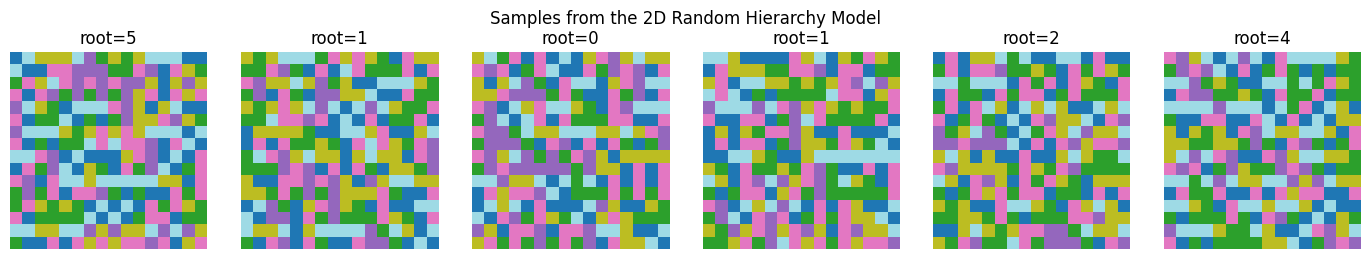

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
for i, ax in enumerate(axes):
    grid, label = train_dataset[i]
    ax.imshow(grid.numpy(), cmap="tab20", vmin=0, vmax=v - 1)
    ax.set_title(f"root={int(label)}")
    ax.axis("off")
fig.suptitle("Samples from the 2D Random Hierarchy Model")
plt.tight_layout()
plt.show()

### The hierarchy underneath one sample

Each sample is built by recursively expanding a root symbol through `L`
levels of `s`x`s` production rules. Here we visualize every level of that
expansion for a single sample (each level upsampled with nearest-neighbor
interpolation to the final resolution for easy comparison).

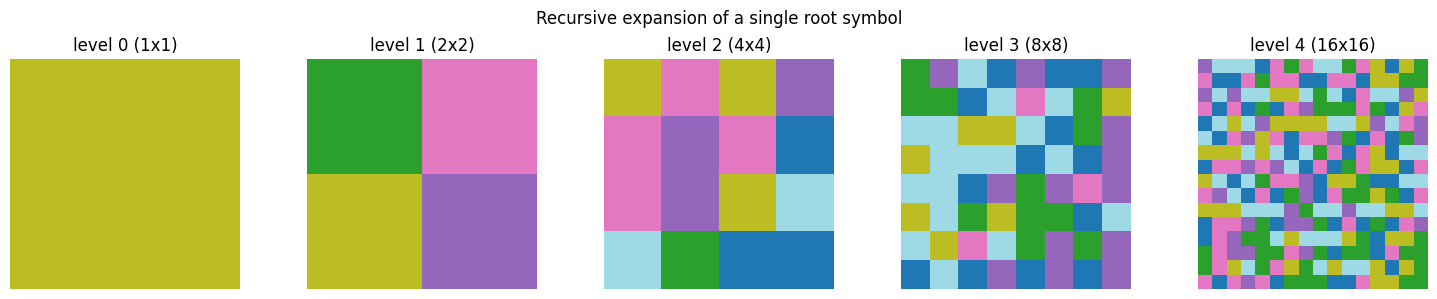

In [5]:
_, _, levels = rhm.sample(1, seed=3, return_hierarchy=True)

fig, axes = plt.subplots(1, L + 1, figsize=(3 * (L + 1), 3))
for l, level in enumerate(levels):
    upsampled = np.kron(level[0], np.ones((grid_size // level.shape[1], grid_size // level.shape[2])))
    axes[l].imshow(upsampled, cmap="tab20", vmin=0, vmax=v - 1)
    axes[l].set_title(f"level {l} ({level.shape[1]}x{level.shape[2]})")
    axes[l].axis("off")
fig.suptitle("Recursive expansion of a single root symbol")
plt.tight_layout()
plt.show()

## 2. Absorbing-state (masking) forward corruption

At noise level `t`, every site is independently replaced by `MASK` with
probability `p_mask(t)`. Unlike Gaussian corruption, an unmasked site is
*never* wrong -- this is what makes exact Bayes-optimal denoising by patch
matching possible.

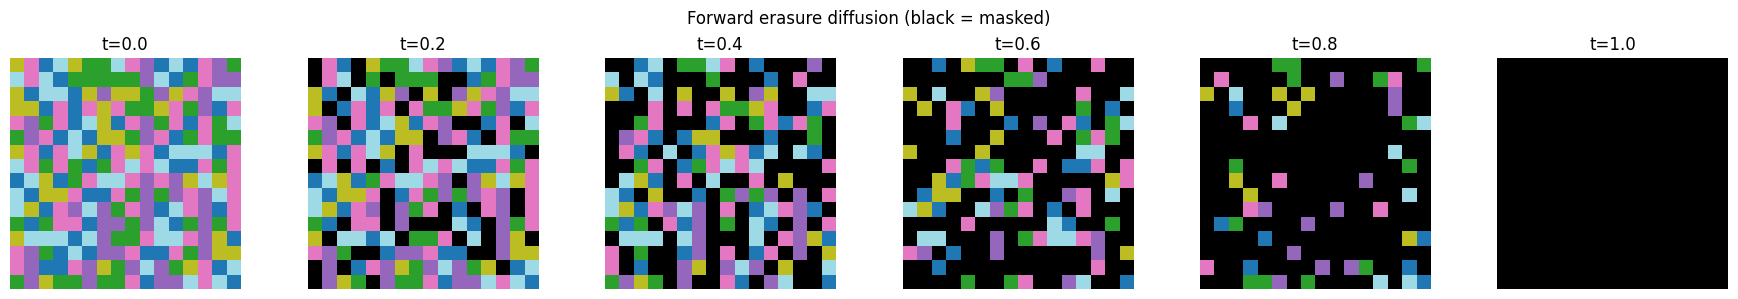

In [6]:
x0, _ = demo_dataset[0]
x0_batch = x0.unsqueeze(0)
mask_token = v  # sentinel id, one past the real vocabulary

ts = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(1, len(ts), figsize=(3 * len(ts), 3))
gen = torch.Generator().manual_seed(0)
for ax, t in zip(axes, ts):
    xt, _ = mask_tokens(x0_batch, linear_mask_schedule(t), mask_token, generator=gen)
    display = xt[0].clone().float()
    display[xt[0] == mask_token] = float("nan")
    cmap = plt.cm.tab20.copy()
    cmap.set_bad(color="black")
    ax.imshow(np.ma.masked_invalid(display.numpy()), cmap=cmap, vmin=0, vmax=v - 1)
    ax.set_title(f"t={t:.1f}")
    ax.axis("off")
fig.suptitle("Forward erasure diffusion (black = masked)")
plt.tight_layout()
plt.show()

## 3. `LocalDiscreteScoreMachine`: exact Bayes-optimal denoising

The machine is built directly from a training set of clean grids -- there is
no learned network, only pattern matching against `k x k` "words" seen in
training data. We mask one held-out sample and reconstruct it.

kernel_size=5, p_mask=0.5: site-wise reconstruction accuracy = 0.766


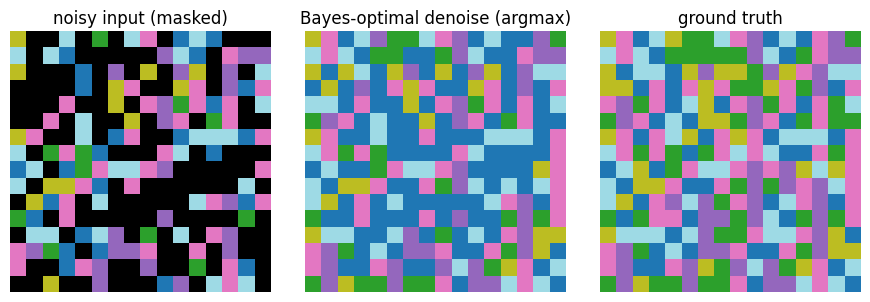

In [7]:
kernel_size = 5
machine = LocalDiscreteScoreMachine(
    train_dataset,
    vocab_size=v,
    kernel_size=kernel_size,
    batch_size=256,
    mask_token=mask_token,
    alpha_smooth=1.0,
    shuffle=False,
)

p_mask = 0.5
xt, mask = mask_tokens(x0_batch, p_mask, mask_token, generator=torch.Generator().manual_seed(1))
posterior = machine(torch.tensor([p_mask]), xt)  # (1, v, H, W)
x0_hat = posterior.argmax(dim=1)

accuracy = (x0_hat == x0_batch).float().mean().item()
print(f"kernel_size={kernel_size}, p_mask={p_mask}: site-wise reconstruction accuracy = {accuracy:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
display = xt[0].clone().float()
display[xt[0] == mask_token] = float("nan")
cmap = plt.cm.tab20.copy()
cmap.set_bad(color="black")
axes[0].imshow(np.ma.masked_invalid(display.numpy()), cmap=cmap, vmin=0, vmax=v - 1)
axes[0].set_title("noisy input (masked)")
axes[1].imshow(x0_hat[0].numpy(), cmap="tab20", vmin=0, vmax=v - 1)
axes[1].set_title("Bayes-optimal denoise (argmax)")
axes[2].imshow(x0_batch[0].numpy(), cmap="tab20", vmin=0, vmax=v - 1)
axes[2].set_title("ground truth")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Effect of patch size and masking level

Larger patches ("words") should carry more of the compositional structure
of the hierarchy and denoise better, especially at high masking levels --
this is the whole point of matching on *patches* rather than single pixels.

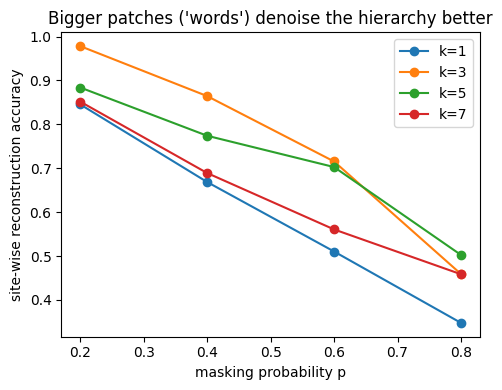

In [8]:
kernel_sizes = [1, 3, 5, 7]
p_masks = [0.2, 0.4, 0.6, 0.8]
n_eval = len(demo_dataset)

acc = np.zeros((len(kernel_sizes), len(p_masks)))
for ki, k in enumerate(kernel_sizes):
    mach_k = LocalDiscreteScoreMachine(
        train_dataset, vocab_size=v, kernel_size=k, batch_size=256,
        mask_token=mask_token, alpha_smooth=1.0, shuffle=False,
    )
    for pi, p in enumerate(p_masks):
        correct, total = 0, 0
        gen = torch.Generator().manual_seed(42)
        for i in range(n_eval):
            xi, _ = demo_dataset[i]
            xi = xi.unsqueeze(0)
            xti, _ = mask_tokens(xi, p, mask_token, generator=gen)
            post = mach_k(torch.tensor([p]), xti)
            xhat = post.argmax(dim=1)
            correct += (xhat == xi).sum().item()
            total += xi.numel()
        acc[ki, pi] = correct / total

fig, ax = plt.subplots(figsize=(5, 4))
for ki, k in enumerate(kernel_sizes):
    ax.plot(p_masks, acc[ki], marker="o", label=f"k={k}")
ax.set_xlabel("masking probability p")
ax.set_ylabel("site-wise reconstruction accuracy")
ax.set_title("Bigger patches ('words') denoise the hierarchy better")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Generating new samples from pure noise

`ScheduledDiscreteScoreMachine` runs the reverse erasure-diffusion process:
starting from an all-`MASK` grid, it reveals sites over `nsteps` following
the masking schedule, sampling each newly revealed site from the local
machine's posterior.

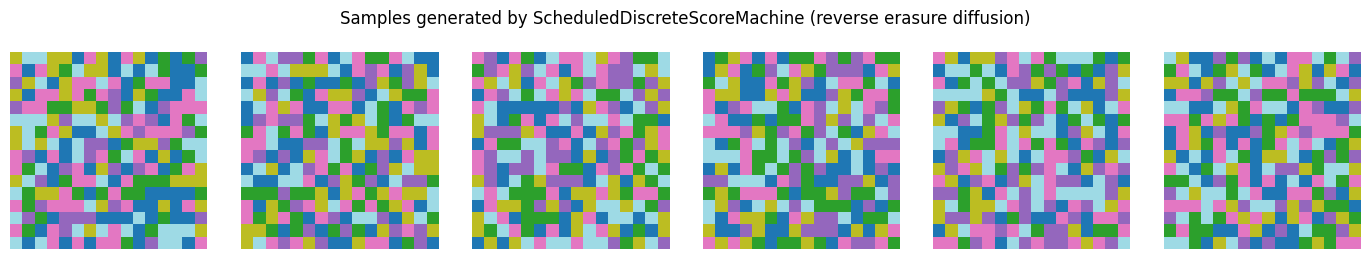

In [9]:
sampler = ScheduledDiscreteScoreMachine(
    machine, vocab_size=v, grid_size=grid_size,
    default_time_steps=40, mask_schedule=cosine_mask_schedule, mask_token=mask_token,
)

gen = torch.Generator().manual_seed(7)
generated = sampler.sample(n_samples=6, device=torch.device("cpu"), generator=gen)

fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
for i, ax in enumerate(axes):
    ax.imshow(generated[i].numpy(), cmap="tab20", vmin=0, vmax=v - 1)
    ax.axis("off")
fig.suptitle("Samples generated by ScheduledDiscreteScoreMachine (reverse erasure diffusion)")
plt.tight_layout()
plt.show()

## 5. Reproducing the compositional phase transition

Sclocchi, Favero & Wyart, ["A phase transition in diffusion models reveals
the hierarchical nature of data,"](https://doi.org/10.1073/pnas.2408799121)
*PNAS* 122(1) e2408799121 (2025), run the following experiment on the (1D)
Random Hierarchy Model: corrupt clean data with forward diffusion up to time
`t`, then run the backward (denoising) process back to `t=0`, and ask
whether each level of the generative tree's latent variables was
reconstructed correctly. They find a sharp transition at a level-dependent
threshold time for **coarse/high-level** latents (e.g. the class, at the top
of the tree), while **fine/low-level** latents change **smoothly** across
the whole range of `t` (their Figs. 5 and 7).

We reproduce this qualitatively with our tools: `ScheduledDiscreteScoreMachine`
now accepts a `t_start` so we can corrupt to time `t` and denoise back to 0
(rather than always starting from pure noise), and we don't have a direct
decoder for the latent tree -- but an exact match of the whole `s**(L-level)`
x `s**(L-level)` block spanned by a level-`level` node is, for a reasonably
large alphabet, only possible if that node's entire subtree (i.e. its
generative path) was reproduced identically, since the model's recursive
production rules make different symbol chains collide at the leaves with
vanishing probability. So "block exactly matches" is a good proxy for
"that level's latent survived denoising".

In [10]:
ph_v, ph_s, ph_L, ph_m = 4, 2, 3, 3
ph_grid = ph_s ** ph_L

ph_rhm = RandomHierarchyModel2D(v=ph_v, s=ph_s, L=ph_L, m=ph_m, seed=10)
ph_train = RandomHierarchy2DDataset(n_samples=1500, model=ph_rhm, seed=11, onehot=False)
ph_eval = RandomHierarchy2DDataset(n_samples=24, model=ph_rhm, seed=12, onehot=False)
ph_mask_token = ph_v

ph_machine = LocalDiscreteScoreMachine(
    ph_train, vocab_size=ph_v, kernel_size=3, batch_size=128,
    mask_token=ph_mask_token, alpha_smooth=1.0, shuffle=False,
)
ph_sampler = ScheduledDiscreteScoreMachine(
    ph_machine, vocab_size=ph_v, grid_size=ph_grid,
    default_time_steps=10, mask_schedule=linear_mask_schedule, mask_token=ph_mask_token,
)

x0_eval = torch.stack([ph_eval[i][0] for i in range(len(ph_eval))])  # (n, H, W)
print(f"phase-transition demo: v={ph_v}, s={ph_s}, L={ph_L}, m={ph_m}, grid {ph_grid}x{ph_grid}, "
      f"{len(ph_train)} training grids, {len(ph_eval)} held-out eval grids")

phase-transition demo: v=4, s=2, L=3, m=3, grid 8x8, 1500 training grids, 24 held-out eval grids


In [11]:
def level_match_rate(x0_batch, xhat_batch, s, L, level):
    # fraction of s**(L-level) x s**(L-level) blocks reproduced exactly
    block = s ** (L - level)
    n, H, W = x0_batch.shape
    nb = H // block
    a = x0_batch.reshape(n, nb, block, nb, block)
    b_ = xhat_batch.reshape(n, nb, block, nb, block)
    match = (a == b_).all(dim=4).all(dim=2)
    return match.float().mean().item()


ts = np.linspace(0.05, 0.95, 7)
levels = list(range(ph_L + 1))
match_rates = np.zeros((len(levels), len(ts)))

for ti, t in enumerate(ts):
    gen = torch.Generator().manual_seed(100 + ti)
    xt, _ = mask_tokens(x0_eval, linear_mask_schedule(t), ph_mask_token, generator=gen)
    xhat = ph_sampler(xt, nsteps=10, t_start=t, device=torch.device("cpu"), generator=gen)
    for li, level in enumerate(levels):
        match_rates[li, ti] = level_match_rate(x0_eval, xhat, ph_s, ph_L, level)
    print(f"t={t:.2f} done")

t=0.05 done


t=0.20 done


t=0.35 done


t=0.50 done


t=0.65 done


t=0.80 done


t=0.95 done


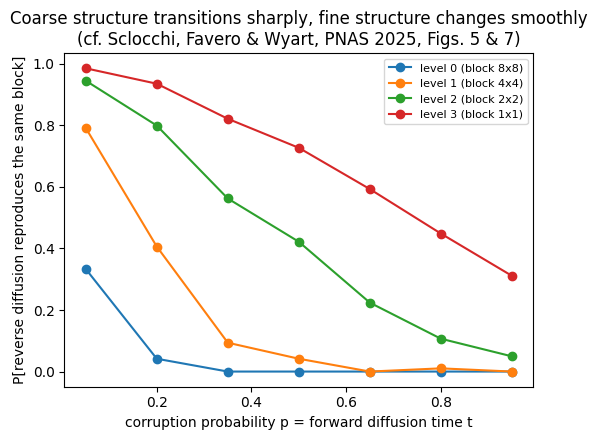

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for li, level in enumerate(levels):
    block = ph_s ** (ph_L - level)
    ax.plot(ts, match_rates[li], marker="o", label=f"level {level} (block {block}x{block})")
ax.set_xlabel("corruption probability p = forward diffusion time t")
ax.set_ylabel("P[reverse diffusion reproduces the same block]")
ax.set_title(
    "Coarse structure transitions sharply, fine structure changes smoothly\n"
    "(cf. Sclocchi, Favero & Wyart, PNAS 2025, Figs. 5 & 7)"
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Coarser levels (small `level`, large blocks close to the root) should fall
off faster and more sharply than finer levels (large `level`, small blocks
near the leaves) -- the same qualitative signature the paper reports for
real diffusion models on natural images: the *class* of a generated image
flips abruptly at a characteristic noise level, while low-level texture
keeps evolving smoothly throughout.

## Takeaways

- The 2D Random Hierarchy Model gives ground-truth compositional structure
  we can probe exactly.
- Because absorbing-state diffusion never corrupts a revealed token, the
  local denoising posterior is *exact* nonparametric Bayes inference over
  training "words" -- no network, no approximation, no likelihood weighting.
- Denoising accuracy improves with patch size, showing the local machine is
  picking up on the hierarchy's multi-scale structure rather than just
  per-pixel statistics.
- The same local machine, used as the reverse-transition model of an
  ancestral sampler, generates fresh samples from pure noise.
- Corrupt-then-denoise experiments at varying `t_start` reproduce the
  qualitative compositional phase transition of Sclocchi, Favero & Wyart
  (PNAS 2025): coarse/high-level structure flips sharply at a threshold
  noise level, while fine/low-level structure degrades smoothly.